# Multi-Class Mental State Classification with BrainFlow and PhasorFlow

Building upon the binary classification notebook, we now tackle a more complex **multi-class** Topological Phase classification problem. 

We will synthesize an $N=32$ channel EEG stream from `BrainFlow` and induce **4 distinct simulated mental states**:
1. **Calm/Resting**: Low variance, high spatial alignment.
2. **Motor Imagery (Left)**: High frequency oscillations localized to the left hemisphere (first 16 threads).
3. **Motor Imagery (Right)**: High frequency oscillations localized to the right hemisphere (last 16 threads).
4. **Flow State/Deep Focus**: Intense inter-hemispheric coherence (symmetric variance but locked phases).

We will train a $32$-thread Variational Phasor Circuit using Softmax probability readout and Categorical Cross-Entropy loss.

In [1]:
import sys
import os
import time
sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import math

# BrainFlow Imports
import brainflow
from brainflow.board_shim import BoardShim, BrainFlowInputParams, BoardIds

import phasorflow as pf

# Set seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)


/opt/anaconda3/lib/python3.13/site-packages/brainflow/board_shim.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 1. Generating 4-Class Synthetic Data
We configure BrainFlow and inject our artificial topological spatial signatures.

In [2]:
BoardShim.enable_dev_board_logger()
params = BrainFlowInputParams()
board_id = BoardIds.SYNTHETIC_BOARD.value
board = BoardShim(board_id, params)

N_CHANNELS = 32

def get_multiclass_brainflow_snapshot(board, state_type, samples=256):
    """Retrieves standard Brainflow snapshots and modulates them into 4 spatial classes."""
    board.insert_marker(1)
    time.sleep(0.05)
    
    data = board.get_current_board_data(samples)
    eeg_channels = BoardShim.get_eeg_channels(board_id)
    raw_features = np.mean(data[eeg_channels, :], axis=1)
    
    # Upsample to 32 dimensions
    base_features = np.interp(np.linspace(0, len(raw_features)-1, N_CHANNELS),
                              np.arange(len(raw_features)), raw_features)
    
    # Class-specific spatial topology injection:
    half = N_CHANNELS // 2
    if state_type == 0:   # 0: Calm
        features = base_features * 0.1 + np.linspace(0, 1, N_CHANNELS)
    elif state_type == 1: # 1: Motor Left
        features = base_features * 0.2
        features[:half] += np.sin(np.linspace(0, 4*np.pi, half)) * 2.5
    elif state_type == 2: # 2: Motor Right
        features = base_features * 0.2
        features[half:] += np.sin(np.linspace(0, 4*np.pi, half)) * 2.5
    elif state_type == 3: # 3: Flow State (Symmetry)
        left_sym = np.random.normal(2, 1.5, half)
        features = np.concatenate([left_sym, left_sym + np.random.normal(0, 0.1, half)])
        
    return features

# Initialize and Stream
board.prepare_session()
board.start_stream(45000, "")

# Generate 200 trials (50 per class)
NUM_CLASSES = 4
X = []
y = []

try:
    print(f"Streaming BrainFlow data for 4 Classes (N=32 Channels)...")
    for i in range(200):
        label = i % NUM_CLASSES
        snapshot = get_multiclass_brainflow_snapshot(board, state_type=label, samples=128)
        X.append(snapshot)
        y.append(label)
        if i % 50 == 0: print(f"  ...collected {i} snapshots")
finally:
    board.stop_stream()
    board.release_session()

X = torch.tensor(np.array(X), dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long)

# Global Phase Normalization [-pi, pi]
X_norm = (X - torch.mean(X, dim=0)) / (torch.std(X, dim=0) + 1e-8)
X_phases = math.pi * torch.tanh(X_norm)

print(f"\nData generation complete: {X_phases.shape}. Target classes: {torch.unique(y)}")

[2026-03-10 22:05:49.597] [board_logger] [info] incoming json: {
    "file": "",
    "file_anc": "",
    "file_aux": "",
    "ip_address": "",
    "ip_address_anc": "",
    "ip_address_aux": "",
    "ip_port": 0,
    "ip_port_anc": 0,
    "ip_port_aux": 0,
    "ip_protocol": 0,
    "mac_address": "",
    "master_board": -100,
    "other_info": "",
    "serial_number": "",
    "serial_port": "",
    "timeout": 0
}
[2026-03-10 22:05:49.597] [board_logger] [trace] Board object created -1


Streaming BrainFlow data for 4 Classes (N=32 Channels)...
  ...collected 0 snapshots


  ...collected 50 snapshots


  ...collected 100 snapshots


  ...collected 150 snapshots



Data generation complete: torch.Size([200, 32]). Target classes: tensor([0, 1, 2, 3])


## 2. Visualizing Class Signatures
Plotting the 32 phase angles across the 4 mental states.

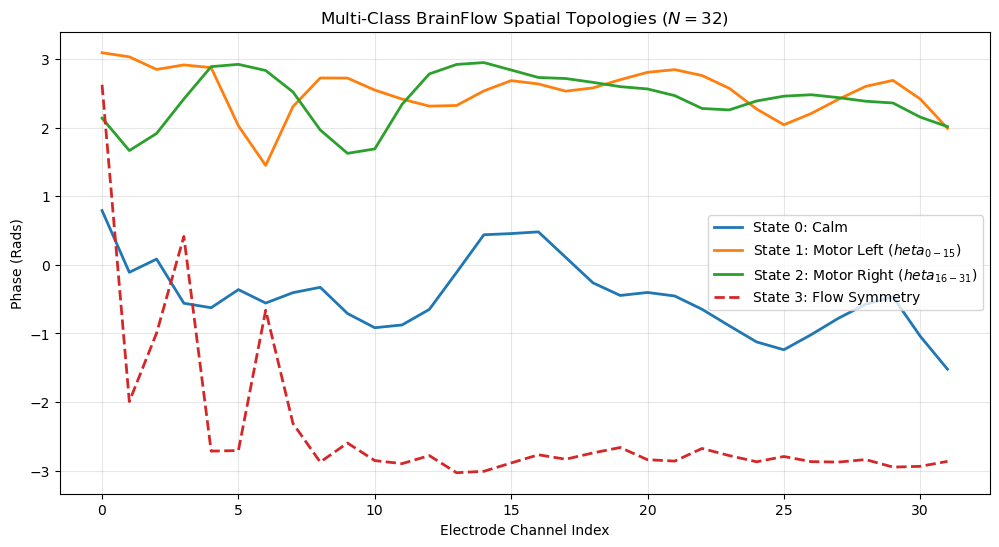

In [3]:
plt.figure(figsize=(12, 6))
plt.plot(X_phases[y == 0][0].numpy(), label="State 0: Calm", lw=2)
plt.plot(X_phases[y == 1][0].numpy(), label="State 1: Motor Left ($\theta_{0-15}$)", lw=2)
plt.plot(X_phases[y == 2][0].numpy(), label="State 2: Motor Right ($\theta_{16-31}$)", lw=2)
plt.plot(X_phases[y == 3][0].numpy(), label="State 3: Flow Symmetry", lw=2, linestyle='--')
plt.title("Multi-Class BrainFlow Spatial Topologies ($N=32$)")
plt.xlabel("Electrode Channel Index")
plt.ylabel("Phase (Rads)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 3. The 32-Thread Variational Phasor Circuit (Softmax Readout)
Because we have 4 target classes, we must extract **4 continuous probabilities**. We achieve this by reading the terminal phase angles of the first 4 threads (`Thread 0`, `Thread 1`, `Thread 2`, `Thread 3`) and passing them through a numerically-stable Softmax function.

In [4]:
backend = pf.Simulator.get_backend("analytic_simulator")

def create_multiclass_vpc(x, weights):
    pc = pf.PhasorCircuit(32)
    
    # 1. State Encoding
    for i in range(32):
        pc.shift(i, x[i])

    # 2. VQC Layer 1
    for i in range(32):
        pc.shift(i, weights[i])
        
    # Spatial Adjacency Entanglement
    for i in range(0, 32 - 1, 2):
        pc.mix(i, i+1)
        
    # 3. VQC Layer 2
    for i in range(32):
        pc.shift(i, weights[i + 32])
        
    # Hemisphere Mixing
    pc.dft()
    
    return pc

def multiclass_vpc_predict(x, weights):
    pc = create_multiclass_vpc(x, weights)
    res = backend.run(pc)
    
    
    # Stable Softmax
    # Scale logits to amplify class differences for Softmax
    # Map the first 4 phases through a sine wave to smooth the Torus boundaries for continuous Autograd gradients
    logits = torch.sin(res['phases'][:4]) * 5.0
    e_x = torch.exp(logits - torch.max(logits))
    return e_x / e_x.sum(dim=0)

def cross_entropy_loss(weights):
    preds = torch.stack([multiclass_vpc_predict(X_phases[i], weights) for i in range(len(X_phases))])
    
    # Negative Log-Likelihood Loss
    loss = -torch.mean(torch.log(preds[torch.arange(len(y)), y] + 1e-9))
    return loss


## 4. Multi-Class Training Routine (Categorical Cross-Entropy)
We use the gradient-free `COBYLA` optimizer to find the 64 optimal phase shifts.

Training Variational Phasor Circuit (Multi-Class BrainFlow)...


Epoch   0 | Loss: 3.4096


Epoch  10 | Loss: 0.6921


Epoch  20 | Loss: 0.4005


Epoch  30 | Loss: 0.3187


...

Epoch  60 | Loss: 0.2188


Epoch  70 | Loss: 0.2087


Epoch  80 | Loss: 0.2103


Epoch  90 | Loss: 0.2065


Final Epoch | Loss: 0.1936
Training complete.


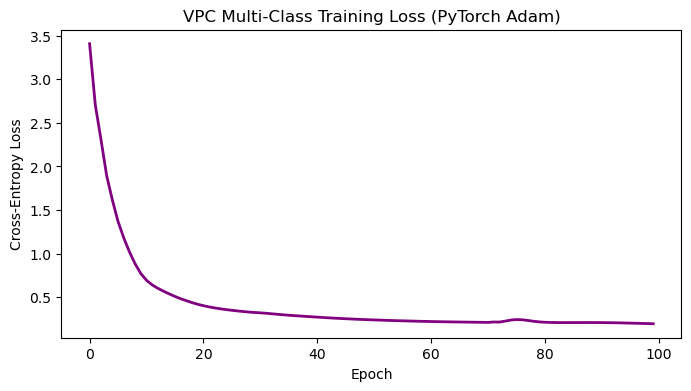

In [5]:
# Initialize 64 parameters as an Autograd-tracked tensor
weights = nn.Parameter(torch.randn(64) * 0.1)

# Adam Optimizer natively traversing the Toplogical Graph
optimizer = optim.Adam([weights], lr=0.05)

EPOCHS = 100
loss_history = []

print("Training Variational Phasor Circuit (Multi-Class BrainFlow)...")
for epoch in range(EPOCHS):
    optimizer.zero_grad()
    loss = cross_entropy_loss(weights)
    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Loss: {loss.item():.4f}")

print(f"Final Epoch | Loss: {loss_history[-1]:.4f}")
print("Training complete.")

plt.figure(figsize=(8, 4))
plt.plot(loss_history, color='purple', lw=2)
plt.title("VPC Multi-Class Training Loss (PyTorch Adam)")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.show()


## 5. System Accuracy & Confusion Matrix
We identify the argmax index of the Softmax output and compare against the 4 ground-truth states.

In [6]:
# Evaluate Accuracy
correct = 0
total = len(X_phases)

with torch.no_grad():
    for i in range(total):
        probs = multiclass_vpc_predict(X_phases[i], weights)
        pred_class = torch.argmax(probs).item()
        
        if pred_class == y[i].item():
            correct += 1

accuracy = correct / total
print(f"Test Accuracy on BrainFlow Multi-Class Data: {accuracy * 100:.2f}%")


Test Accuracy on BrainFlow Multi-Class Data: 99.00%
